# GradientBoosting — entrenamiento y batería de pruebas de overfitting

**Modelo:** `GradientBoostingRegressor` con los hiperparámetros elegidos
(`n_estimators=300, max_depth=8, min_samples_leaf=5`).

**Por qué esta batería y no solo mirar el RMSE de test:** con `max_depth=8`
cada árbol individual del ensamble ya es bastante expresivo — en boosting
eso es una señal de alerta temprana, porque cada corrector sucesivo puede
terminar ajustando ruido específico del set de entrenamiento en vez de
señal real. Un solo número de RMSE de test no distingue "generaliza bien"
de "tuvo suerte con ese split particular". Este notebook corre 5 pruebas
distintas, cada una diseñada para exponer un síntoma distinto de
overfitting que un RMSE agregado puede esconder.

**Entrada:** `GET /features/history` del Data Service (mismo contrato que
los notebooks anteriores — RNF17).


In [5]:
import warnings
warnings.filterwarnings("ignore")

import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 0. Carga de datos vía la API del Data Service

In [6]:
# Bootstrap: pide la data al Data Service por HTTP (tal como lo hará el
# ML Service en producción) en vez de importar DataPipeline o leer un CSV
# local. Esto valida de una vez que el contrato de la API es el correcto.
DATA_SERVICE_URL = "http://localhost:8000"  # ajusta si tu Data Service corre en otro host/puerto
PAIR_CODE = "SP500_VIX"

# Contrato de columnas que el ML Service espera recibir. A diferencia del
# esquema anterior (importado directamente de DataPipeline.feature_schema),
# este vive en el propio ML Service: los microservicios no comparten
# código, cada uno valida el contrato por su cuenta (RNF17).
EXPECTED_FEATURE_COLUMNS = [
    "main_log_return", "main_log_range", "main_body_log",
    "main_upper_wick_log", "main_lower_wick_log",
    "main_vol_5d", "main_vol_10d",
    "vol_idx_log_close", "vol_idx_log_range", "vol_idx_log_return",
    "day_of_week", "target_range_next_day",
]

response = requests.get(f"{DATA_SERVICE_URL}/features/history", params={"pair_code": PAIR_CODE}, timeout=30)
response.raise_for_status()
rows = response.json()
assert rows, f"El Data Service no devolvió filas para {PAIR_CODE}."

df = pd.DataFrame(rows)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

missing = set(EXPECTED_FEATURE_COLUMNS) - set(df.columns)
assert not missing, f"Faltan columnas esperadas del esquema: {missing}"

versions = df["schema_version"].unique()
assert len(versions) == 1, (
    f"Se mezclaron filas de más de una versión de esquema: {versions} — "
    "RNF12: no se debe modelar sobre un esquema inconsistente."
)

print(f"Par:                {PAIR_CODE}")
print(f"Filas:              {len(df)}")
print(f"Rango de fechas:    {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Versión de esquema: {versions[0]}")

# El resto del notebook trabaja con "date" como índice (igual que el CSV
# anterior) y solo con las columnas de features/target — las columnas de
# auditoría (pair_code, schema_version, computed_at, updated_at) ya
# cumplieron su función en la validación de arriba y no se necesitan
# para el EDA ni el modelado.
df = df.set_index("date")[EXPECTED_FEATURE_COLUMNS]

print(f"Columnas de trabajo ({len(df.columns)}): {list(df.columns)}")
df.head()


Par:                SP500_VIX
Filas:              5411
Rango de fechas:    2005-01-18 → 2026-07-22
Versión de esquema: v1
Columnas de trabajo (12): ['main_log_return', 'main_log_range', 'main_body_log', 'main_upper_wick_log', 'main_lower_wick_log', 'main_vol_5d', 'main_vol_10d', 'vol_idx_log_close', 'vol_idx_log_range', 'vol_idx_log_return', 'day_of_week', 'target_range_next_day']


,main_log_return,main_log_range,main_body_log,main_upper_wick_log,main_lower_wick_log,main_vol_5d,main_vol_10d,vol_idx_log_close,vol_idx_log_range,vol_idx_log_return,day_of_week,target_range_next_day
date,,,,,,,,,,,,
2005-01-18,0.009628,0.013367,0.009628,0.000000,0.003738,0.007942,0.006923,2.523326,0.066822,0.003213,1,0.009721
2005-01-19,-0.009535,0.009721,-0.009535,0.000000,0.000186,0.008803,0.006550,2.578701,0.062472,0.055375,2,0.009508
2005-01-20,-0.007813,0.009508,-0.007813,0.000000,0.001694,0.009138,0.006911,2.626840,0.060625,0.048140,3,0.009909
2005-01-21,-0.006435,0.009909,-0.006435,0.003431,0.000043,0.008783,0.006953,2.664447,0.076132,0.037606,4,0.007943
2005-01-24,-0.003534,0.007943,-0.003534,0.004409,0.000000,0.007681,0.006976,2.684440,0.040116,0.019994,0,0.009025


## 1. Configuración del modelo e hiperparámetros

Un solo lugar para los hiperparámetros — todas las celdas de este notebook
(split principal, curva de validación, walk-forward) los leen de aquí.
Cambia estos valores y vuelve a correr todo el notebook para probar otra
configuración, sin tener que editar cada celda por separado.


In [7]:
HYPERPARAMS = {
    "learning_rate": 0.05,
    "max_depth": 2,
    "min_samples_leaf": 5,
    "n_estimators": 200,
    "subsample": 0.9,
    "random_state": RANDOM_STATE,
}

FEATURE_COLS = [c for c in EXPECTED_FEATURE_COLUMNS if c != "target_range_next_day"]

def build_model(**overrides):
    """Crea una instancia nueva de GradientBoostingRegressor con
    HYPERPARAMS, permitiendo sobrescribir puntualmente (usado en la curva
    de validación para variar n_estimators sin tocar el resto)."""
    params = {**HYPERPARAMS, **overrides}
    return GradientBoostingRegressor(**params)

print("Hiperparámetros:", HYPERPARAMS)


Hiperparámetros: {'learning_rate': 0.05, 'max_depth': 2, 'min_samples_leaf': 5, 'n_estimators': 200, 'subsample': 0.9, 'random_state': 42}


## 2. Split cronológico train/test y entrenamiento base

División 80/20 **sin mezclar** (nunca `train_test_split` con `shuffle=True`
en series de tiempo — eso dejaría que el modelo "vea" fechas futuras
durante el entrenamiento). Este es el split que se usa como referencia
principal en las Pruebas 1, 2 y 3; la Prueba 4 usa Walk-Forward completo
con múltiples folds.


In [8]:
X = df[FEATURE_COLS].values
y = df["target_range_next_day"].values

split_idx = int(len(df) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

train_dates = df.index[:split_idx]
test_dates = df.index[split_idx:]

print(f"Train: {len(X_train)} filas  ({train_dates.min().date()} → {train_dates.max().date()})")
print(f"Test:  {len(X_test)} filas  ({test_dates.min().date()} → {test_dates.max().date()})")

modelo = build_model()
modelo.fit(X_train, y_train)
print("\nModelo entrenado.")


Train: 4328 filas  (2005-01-18 → 2022-03-25)
Test:  1083 filas  (2022-03-28 → 2026-07-22)

Modelo entrenado.


In [9]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.ensemble import GradientBoostingRegressor

# 1. Cuadrícula de parámetros
param_grid = {
    "n_estimators": [200, 300, 400],
    "learning_rate": [0.01, 0.05],
    "max_depth": [2, 3, 4],
    "subsample": [0.7, 0.8, 0.9],
    "min_samples_leaf": [5, 10, 15]
}

# 2. Validación cruzada para series de tiempo
tscv = TimeSeriesSplit(n_splits=5)

# 3. Configurar la búsqueda
modelo_base = GradientBoostingRegressor(random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    estimator=modelo_base,
    param_grid=param_grid,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1 # Reduje el verbose a 1 para que no sature tu pantalla
)

# 4. Entrenar usando el split que ya hiciste en la Celda 2
print("Iniciando Grid Search (esto puede tomar varios minutos)...")
grid_search.fit(X_train, y_train)

# 5. Mostrar resultados
print("\n=== BÚSQUEDA FINALIZADA ===")
print("Mejores parámetros:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")

# 6. EL TRUCO PARA NO TOCAR TU CELDA 3:
# Sobreescribimos la variable 'modelo' con el mejor modelo ya entrenado
modelo = grid_search.best_estimator_
print("\nVariable 'modelo' actualizada. Lista para la Celda 3.")

Iniciando Grid Search (esto puede tomar varios minutos)...
Fitting 5 folds for each of 162 candidates, totalling 810 fits

=== BÚSQUEDA FINALIZADA ===
Mejores parámetros:
  learning_rate: 0.05
  max_depth: 2
  min_samples_leaf: 5
  n_estimators: 200
  subsample: 0.9

Variable 'modelo' actualizada. Lista para la Celda 3.


## Prueba 1 — RMSE, MAE y R² en train vs. test

**Qué se busca:** una brecha entre train y test en más de una métrica a la
vez. RMSE castiga errores grandes más que MAE (por el cuadrado); si el gap
de RMSE es grande pero el de MAE es chico (o viceversa), el modelo está
fallando de forma distinta en errores típicos vs. errores extremos — algo
que una sola métrica no revela.

**Señal de overfitting:** `RMSE_test` y `MAE_test` notablemente peores que
sus versiones de train, **y** `R²_test` mucho menor que `R²_train` (el
modelo explica varianza en datos que ya vio, pero no en datos nuevos).


In [10]:
def metricas(y_true, y_pred):
    return {
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
        "mae": mean_absolute_error(y_true, y_pred),
        "r2": r2_score(y_true, y_pred),
    }

pred_train = modelo.predict(X_train)
pred_test = modelo.predict(X_test)

m_train = metricas(y_train, pred_train)
m_test = metricas(y_test, pred_test)

prueba1 = pd.DataFrame([
    {"conjunto": "Train", **m_train},
    {"conjunto": "Test", **m_test},
    {"conjunto": "Gap (test - train)",
     "rmse": m_test["rmse"] - m_train["rmse"],
     "mae": m_test["mae"] - m_train["mae"],
     "r2": m_test["r2"] - m_train["r2"]},
])
prueba1


,conjunto,rmse,mae,r2
0,Train,0.00547,0.003778,0.716961
1,Test,0.00536,0.003721,0.508197
2,Gap (test - train),-0.00011,-0.000057,-0.208764


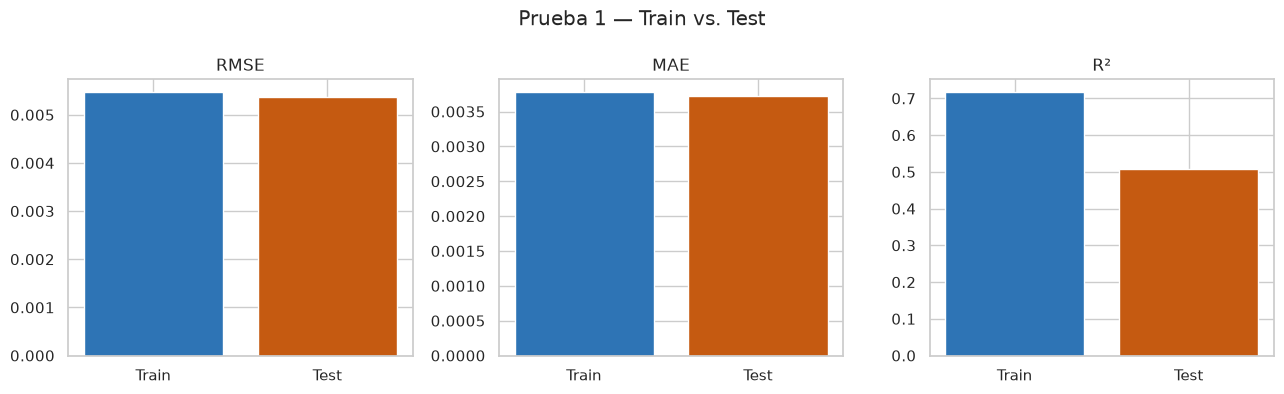

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, metric, label in zip(axes, ["rmse", "mae", "r2"], ["RMSE", "MAE", "R²"]):
    ax.bar(["Train", "Test"], [m_train[metric], m_test[metric]], color=["#2E74B5", "#C55A11"])
    ax.set_title(label)
plt.suptitle("Prueba 1 — Train vs. Test")
plt.tight_layout()
plt.show()


## Prueba 2 — Desempeño por régimen de volatilidad (normal vs. crisis)

**Qué se busca:** un RMSE agregado bueno puede esconder que el modelo
memorizó el régimen normal (la mayoría de los días) y falla justo en los
períodos de crisis — que son la minoría de las filas, pero el motivo por
el que existe este modelo (predecir volatilidad "aburrida" es fácil;
anticipar que se viene un salto es lo valioso).

Los umbrales de régimen se calculan **solo con el set de entrenamiento**
(no con todo el dataset) para no filtrar información de la distribución
del test hacia la definición de las categorías.

**Señal de overfitting:** el gap train→test es mucho peor dentro del
régimen de "Crisis" que dentro de "Normal", aunque el promedio general se
vea sano.


In [12]:
CRISIS_QUANTILE = 0.75  # el 25% de días con vol_idx_log_close más alto se etiqueta "Crisis"

umbral_crisis = np.quantile(df["vol_idx_log_close"].values[:split_idx], CRISIS_QUANTILE)
print(f"Umbral de régimen (calculado solo con train): vol_idx_log_close >= {umbral_crisis:.4f} → Crisis")

def etiquetar_regimen(vol_idx_log_close, umbral):
    return np.where(vol_idx_log_close >= umbral, "Crisis", "Normal")

regimen_train = etiquetar_regimen(df["vol_idx_log_close"].values[:split_idx], umbral_crisis)
regimen_test = etiquetar_regimen(df["vol_idx_log_close"].values[split_idx:], umbral_crisis)

def rmse_mae_por_regimen(y_true, y_pred, regimen, conjunto):
    out = []
    for r in ["Normal", "Crisis"]:
        mask = regimen == r
        if mask.sum() == 0:
            continue
        out.append({
            "conjunto": conjunto, "regimen": r, "n": int(mask.sum()),
            "rmse": np.sqrt(mean_squared_error(y_true[mask], y_pred[mask])),
            "mae": mean_absolute_error(y_true[mask], y_pred[mask]),
        })
    return out

prueba2 = pd.DataFrame(
    rmse_mae_por_regimen(y_train, pred_train, regimen_train, "Train") +
    rmse_mae_por_regimen(y_test, pred_test, regimen_test, "Test")
)
prueba2


Umbral de régimen (calculado solo con train): vol_idx_log_close >= 3.1040 → Crisis


,conjunto,regimen,n,rmse,mae
0,Train,Normal,3246,0.004074,0.002981
1,Train,Crisis,1082,0.008360,0.006169
2,Test,Normal,851,0.004343,0.003178
3,Test,Crisis,232,0.008059,0.005711


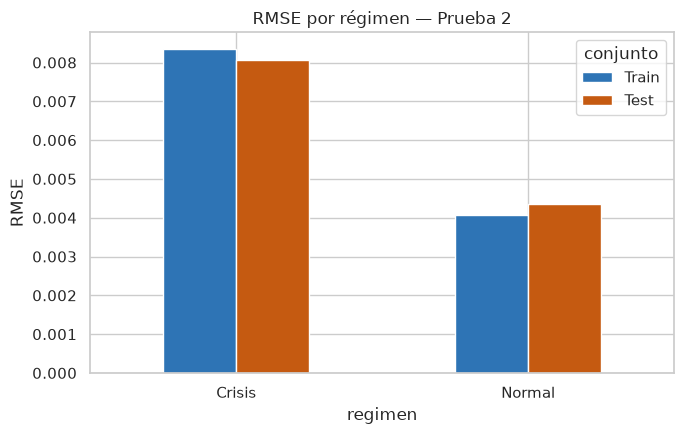


Gap (Test - Train) por régimen:
regimen
Crisis   -0.000301
Normal    0.000269
Name: gap, dtype: float64


In [13]:
pivot_rmse = prueba2.pivot(index="regimen", columns="conjunto", values="rmse")
pivot_rmse["gap"] = pivot_rmse["Test"] - pivot_rmse["Train"]

fig, ax = plt.subplots(figsize=(7, 4.5))
pivot_rmse[["Train", "Test"]].plot(kind="bar", ax=ax, color=["#2E74B5", "#C55A11"])
ax.set_title("RMSE por régimen — Prueba 2")
ax.set_ylabel("RMSE")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

print("\nGap (Test - Train) por régimen:")
print(pivot_rmse["gap"])


## Prueba 3 — Curva de validación vs. `n_estimators`

**Qué se busca:** con `n_estimators` fijo en 300 nunca se ve si el modelo
ya pasó su punto óptimo. En boosting, el síntoma clásico es que el error
de train sigue bajando indefinidamente conforme se agregan árboles,
mientras el error de test toca un mínimo y después empieza a **subir** — el
modelo sigue "aprendiendo" el ruido específico del set de entrenamiento en
cada árbol nuevo.

**Señal de overfitting:** la curva de test se aplana o sube antes de
llegar a 300 árboles, mientras la de train sigue bajando — eso significa
que `n_estimators=300` está más allá del punto óptimo real.


In [14]:
n_range = [25, 50, 100, 150, 200, 250, 300, 400, 500, 600]
curva = []
for n in n_range:
    m = build_model(n_estimators=n)
    m.fit(X_train, y_train)
    curva.append({
        "n_estimators": n,
        "rmse_train": np.sqrt(mean_squared_error(y_train, m.predict(X_train))),
        "rmse_test": np.sqrt(mean_squared_error(y_test, m.predict(X_test))),
    })
curva_df = pd.DataFrame(curva)
curva_df


,n_estimators,rmse_train,rmse_test
0,25,0.006783,0.005847
1,50,0.006083,0.005482
2,100,0.005734,0.005348
3,150,0.005588,0.005347
4,200,0.005470,0.005360
5,250,0.005371,0.005382
6,300,0.005294,0.005405
7,400,0.005161,0.005462
8,500,0.005059,0.005492
9,600,0.004953,0.005517


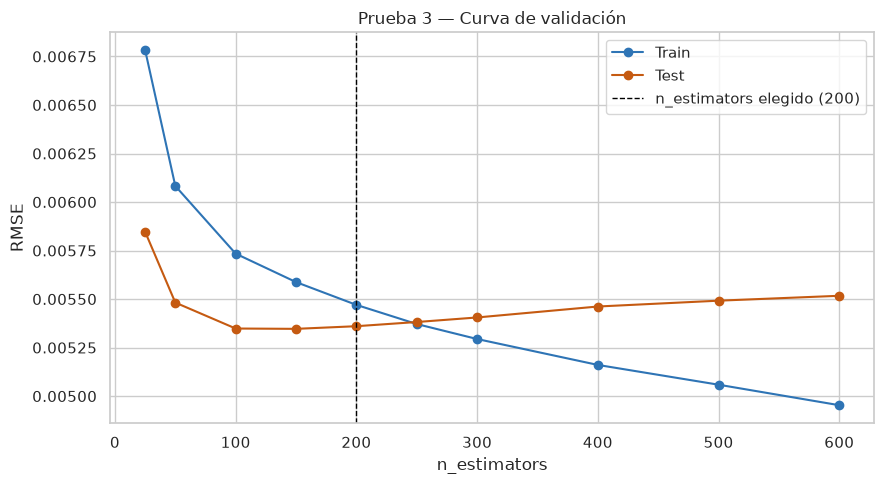

n_estimators con menor RMSE de test en esta curva: 150
n_estimators elegido: 200


In [15]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(curva_df["n_estimators"], curva_df["rmse_train"], label="Train", marker="o", color="#2E74B5")
ax.plot(curva_df["n_estimators"], curva_df["rmse_test"], label="Test", marker="o", color="#C55A11")
ax.axvline(HYPERPARAMS["n_estimators"], color="black", linestyle="--", linewidth=1,
           label=f"n_estimators elegido ({HYPERPARAMS['n_estimators']})")
ax.set_xlabel("n_estimators")
ax.set_ylabel("RMSE")
ax.set_title("Prueba 3 — Curva de validación")
ax.legend()
plt.tight_layout()
plt.show()

optimo = curva_df.loc[curva_df["rmse_test"].idxmin(), "n_estimators"]
print(f"n_estimators con menor RMSE de test en esta curva: {optimo}")
print(f"n_estimators elegido: {HYPERPARAMS['n_estimators']}")


## Prueba 4 — Estabilidad entre folds (Walk-Forward Validation)

**Qué se busca:** el split único de la Prueba 1 depende de dónde cayó la
frontera train/test — si justo separó un período inusual, el resultado
puede ser optimista o pesimista por casualidad. Walk-Forward con ventana
expansiva repite el entrenamiento en 5 ventanas temporales distintas, cada
una con su propio conjunto de prueba inmediatamente posterior (mismo
principio anti-leakage de RF03, aplicado a la validación).

**Señal de overfitting:** la brecha (`RMSE_test − RMSE_train`) es
consistentemente positiva y de magnitud similar en la mayoría de los
folds (patrón real, no ruido de un solo fold) — a diferencia de un
promedio bueno que en realidad esconde un fold atípico compensando a los
demás.


In [16]:
def walk_forward_validate_mensual(df, feature_cols, target_col, build_model,
                                    extract_importance, min_train_months=24):
    """Walk-Forward Validation con reentrenamiento MENSUAL -- simula
    exactamente el escenario de produccion (RF08): al cierre de cada mes,
    el modelo se reentrena con TODO el historico disponible hasta ese
    momento, y sirve predicciones para todos los dias habiles del mes
    siguiente. Cada fold es un mes calendario real, no un bloque de filas
    de tamano arbitrario -- el mismo ciclo que correria el scheduler
    mensual del ML Service en produccion.

    min_train_months: cuantos meses de historia minima se exigen antes de
    empezar a evaluar (evita entrenar los primeros folds con muy pocos
    datos).
    """
    trabajo = df.copy()
    trabajo["_year_month"] = trabajo.index.to_period("M")
    meses = sorted(trabajo["_year_month"].unique())

    metric_rows = []
    importance_rows = []
    fold = 0
    for i in range(min_train_months, len(meses)):
        mes_test = meses[i]
        train_mask = trabajo["_year_month"] < mes_test
        test_mask = trabajo["_year_month"] == mes_test

        X_tr = trabajo.loc[train_mask, feature_cols].values
        y_tr = trabajo.loc[train_mask, target_col].values
        X_te = trabajo.loc[test_mask, feature_cols].values
        y_te = trabajo.loc[test_mask, target_col].values

        if len(X_tr) == 0 or len(X_te) == 0:
            continue

        fold += 1
        model = build_model()
        model.fit(X_tr, y_tr)
        train_pred = model.predict(X_tr)
        test_pred = model.predict(X_te)

        metric_rows.append({
            "fold": fold, "mes": str(mes_test),
            "n_train": len(y_tr), "n_test": len(y_te),
            "train_rmse": np.sqrt(mean_squared_error(y_tr, train_pred)),
            "test_rmse": np.sqrt(mean_squared_error(y_te, test_pred)),
            "train_mae": mean_absolute_error(y_tr, train_pred),
            "test_mae": mean_absolute_error(y_te, test_pred),
        })
        importance_rows.append({
            "fold": fold, "mes": str(mes_test),
            **dict(zip(feature_cols, extract_importance(model))),
        })

    return pd.DataFrame(metric_rows), pd.DataFrame(importance_rows)


fold_metrics, fold_importances = walk_forward_validate_mensual(
    df, FEATURE_COLS, "target_range_next_day", build_model,
    extract_importance=lambda m: m.feature_importances_,
    min_train_months=24,  # ~2 años de historia minima antes del primer mes evaluado
)
fold_metrics["brecha_rmse"] = fold_metrics["test_rmse"] - fold_metrics["train_rmse"]
print(f"Meses evaluados (cada uno = un reentrenamiento simulado): {len(fold_metrics)}")
fold_metrics.head(10)


Meses evaluados (cada uno = un reentrenamiento simulado): 235


,fold,mes,n_train,n_test,train_rmse,test_rmse,train_mae,test_mae,brecha_rmse
0,1,2007-01,493,20,0.002533,0.002571,0.001960,0.002009,0.000038
1,2,2007-02,513,19,0.002551,0.008498,0.001973,0.004086,0.005947
2,3,2007-03,532,22,0.002684,0.004452,0.002007,0.003285,0.001768
3,4,2007-04,554,20,0.002749,0.002640,0.002050,0.002288,-0.000109
4,5,2007-05,574,22,0.002749,0.003120,0.002035,0.002664,0.000371
5,6,2007-06,596,21,0.002739,0.003335,0.002061,0.002594,0.000595
6,7,2007-07,617,21,0.002767,0.007225,0.002079,0.005855,0.004458
7,8,2007-08,638,23,0.002859,0.007376,0.002156,0.006483,0.004516
8,9,2007-09,661,19,0.003038,0.006446,0.002267,0.005563,0.003407
9,10,2007-10,680,23,0.003076,0.006451,0.002295,0.005638,0.003375


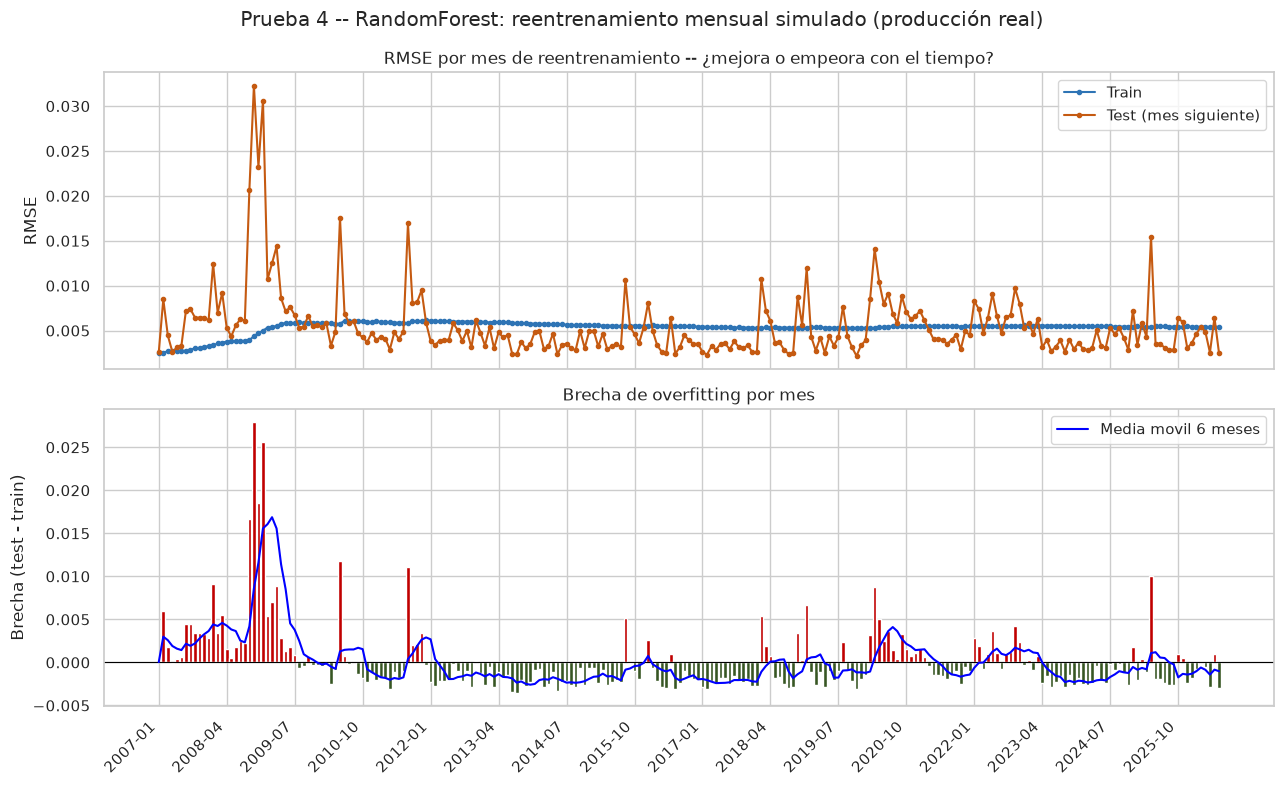

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

axes[0].plot(fold_metrics["mes"], fold_metrics["train_rmse"], label="Train", color="#2E74B5", marker="o", markersize=3)
axes[0].plot(fold_metrics["mes"], fold_metrics["test_rmse"], label="Test (mes siguiente)", color="#C55A11", marker="o", markersize=3)
axes[0].set_ylabel("RMSE")
axes[0].set_title("RMSE por mes de reentrenamiento -- ¿mejora o empeora con el tiempo?")
axes[0].legend()

colors = ["#C00000" if v > 0 else "#375623" for v in fold_metrics["brecha_rmse"]]
axes[1].bar(fold_metrics["mes"], fold_metrics["brecha_rmse"], color=colors)
axes[1].axhline(0, color="black", linewidth=0.8)
media_movil = fold_metrics["brecha_rmse"].rolling(6, min_periods=1).mean()
axes[1].plot(fold_metrics["mes"], media_movil.values, color="blue", linewidth=1.5, label="Media movil 6 meses")
axes[1].set_ylabel("Brecha (test - train)")
axes[1].set_title("Brecha de overfitting por mes")
axes[1].legend()

n_ticks = 15
step = max(1, len(fold_metrics) // n_ticks)
for ax in axes:
    ax.set_xticks(range(0, len(fold_metrics), step))
    ax.set_xticklabels(fold_metrics["mes"].iloc[::step], rotation=45, ha="right")

plt.suptitle("Prueba 4 -- RandomForest: reentrenamiento mensual simulado (producción real)")
plt.tight_layout()
plt.show()



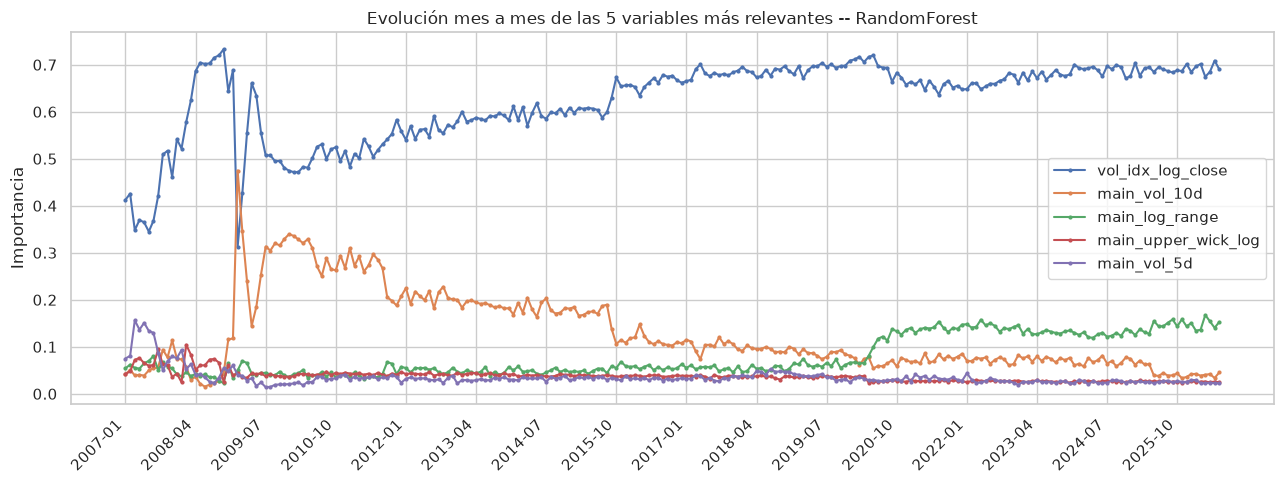

In [18]:
imp_matrix = fold_importances.set_index("mes")[FEATURE_COLS]

# Con potencialmente muchos meses, un heatmap se vuelve ilegible -- se
# grafica la evolucion temporal de las top-5 variables en vez de una
# matriz completa.
top_features = imp_matrix.mean().sort_values(ascending=False).index[:5]

fig, ax = plt.subplots(figsize=(13, 5))
for feat in top_features:
    ax.plot(range(len(imp_matrix)), imp_matrix[feat].values, label=feat, marker="o", markersize=2)

step = max(1, len(imp_matrix) // 15)
ax.set_xticks(range(0, len(imp_matrix), step))
ax.set_xticklabels(imp_matrix.index[::step], rotation=45, ha="right")
ax.set_ylabel("Importancia")
ax.set_title("Evolución mes a mes de las 5 variables más relevantes -- RandomForest")
ax.legend()
plt.tight_layout()
plt.show()

## Prueba 5 — Estabilidad de la importancia de variables entre folds

**Qué se busca:** si el ranking de variables más importantes cambia mucho
de un fold a otro, el modelo no está aprendiendo una relación estable
entre features y target — está ajustándose a particularidades de cada
ventana temporal específica. Esto es una forma de overfitting que el RMSE
promedio no muestra directamente: el modelo puede tener buen RMSE en cada
fold *por razones distintas* en cada uno.

**Señal de overfitting:** variables con importancia alta en un fold y casi
nula en el siguiente (coeficiente de variación alto). Una variable
genuinamente predictiva debería mantener importancia relativamente
consistente fold a fold.


In [21]:
estabilidad = pd.DataFrame({
    "media": imp_matrix.mean(),
    "std": imp_matrix.std(),
})
# Coeficiente de variación: std/media. Alto = importancia inestable entre folds.
estabilidad["coef_variacion"] = estabilidad["std"] / estabilidad["media"].replace(0, np.nan)
estabilidad = estabilidad.sort_values("coef_variacion", ascending=False)
estabilidad


,media,std,coef_variacion
day_of_week,0.005147,0.006078,1.180867
vol_idx_log_return,0.014195,0.011452,0.806754
main_vol_10d,0.128415,0.084839,0.660663
main_log_return,0.019630,0.011268,0.573991
main_body_log,0.017724,0.009972,0.562625
main_vol_5d,0.035375,0.019282,0.545069
main_log_range,0.078320,0.041380,0.528349
vol_idx_log_range,0.017392,0.008541,0.491067
main_lower_wick_log,0.023528,0.010286,0.437186
main_upper_wick_log,0.037264,0.011726,0.314679


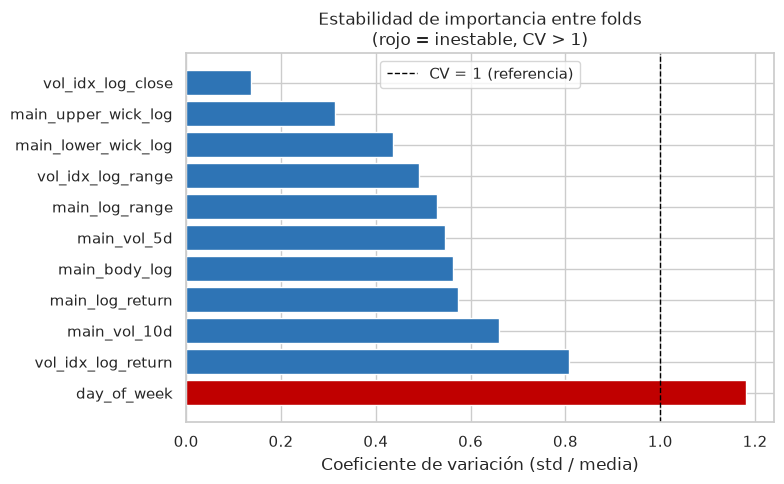

In [22]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#C00000" if v > 1 else "#2E74B5" for v in estabilidad["coef_variacion"]]
ax.barh(estabilidad.index, estabilidad["coef_variacion"], color=colors)
ax.axvline(1, color="black", linestyle="--", linewidth=1, label="CV = 1 (referencia)")
ax.set_xlabel("Coeficiente de variación (std / media)")
ax.set_title("Estabilidad de importancia entre folds\n(rojo = inestable, CV > 1)")
ax.legend()
plt.tight_layout()
plt.show()


## Resumen de las 5 pruebas

Completa esta tabla con lo observado en tu corrida real antes de decidir
si el modelo pasa a la Fase 4 del plan del ML Service (compuerta de
validación antes de promover a producción):

| Prueba | Qué mirar | ¿Hay señal de overfitting? |
|---|---|---|
| 1 — Train vs Test | Gap de RMSE, MAE y R² simultáneamente | |
| 2 — Por régimen | Gap específicamente en "Crisis" | |
| 3 — Curva de validación | ¿300 está después del mínimo de la curva de test? | |
| 4 — Walk-Forward | ¿La brecha es consistente entre folds o la domina uno solo? | |
| 5 — Importancia por fold | ¿Hay variables con CV > 1? | |

Si **2 o más** de estas 5 pruebas muestran señal de overfitting, vale la
pena reconsiderar `max_depth=8` (bajarlo a 4-5, que es más típico para
boosting) antes de registrar este modelo como `production` en MLflow.


In [20]:
print(HYPERPARAMS)

{'learning_rate': 0.05, 'max_depth': 2, 'min_samples_leaf': 5, 'n_estimators': 200, 'subsample': 0.9, 'random_state': 42}
